# Quantum Pattern Generation — FRQI
In the first challenge, Quantum Image Lab: The FRQI Challenge, you were introduced to the FRQI encoding of an image into a quantum state.

It is now time to deep dive into the transformation and generation of quantum visuals using the FRQI encoding.
You will be given target patterns and tasked to build a FRQI circuit that can reproduce them.

### Challenge Outline
1. **Random Noise**

2. **Quantum Checkerboard**

3. **Horizontal and vertical lines**

4. **Nested Squares**

5. **Grayscale Nested Squares**

6. **Quantum Fractals** *(bonus)*


In [1]:
import math
from qiskit import QuantumCircuit
import numpy as np
import matplotlib.pyplot as plt
import importlib

# Import utility functions
import utils_quantum
importlib.reload(utils_quantum)
from utils_quantum import run_simulation
from utils_images import display_image

## Pattern 1 - Random Noise
You must produce a fully random image, like TV static. Each pixel is drawn independently from the others, with a 50% chance of being black and a 50% chance of being white. Here are 4 examples of what we're looking for:

![random_pattern.png](images/random_noise.png)

[[0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 1. 1. 1.]
 [0. 0. 1. 1. 0. 1. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 1. 1. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1. 1. 0. 0. 1. 1. 0. 0. 1. 0. 1. 0.]
 [1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 0. 1. 0. 0. 1. 0.]
 [1. 1. 0. 1. 0. 1. 1. 0. 1. 0. 1. 0. 1. 0. 0. 1.]
 [1. 1. 0. 0. 1. 0. 0. 1. 1. 0. 0. 1. 0. 1. 0. 0.]
 [1. 0. 0. 1. 0. 1. 0. 0. 1. 0. 0. 0. 1. 1. 0. 1.]
 [1. 0. 1. 1. 1. 0. 1. 1. 1. 0. 1. 1. 0. 0. 1. 0.]
 [0. 1. 0. 0. 0. 0. 1. 1. 0. 0. 1. 0. 1. 1. 0. 0.]
 [0. 0. 0. 1. 0. 1. 0. 0. 1. 1. 1. 0. 1. 1. 0. 0.]
 [1. 1. 1. 1. 1. 0. 1. 0. 0. 1. 1. 1. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0.]
 [1. 1. 0. 1. 1. 1. 1. 0. 1. 0. 1. 0. 0. 0. 1. 1.]
 [1. 1. 1. 1. 0. 1. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0.]]


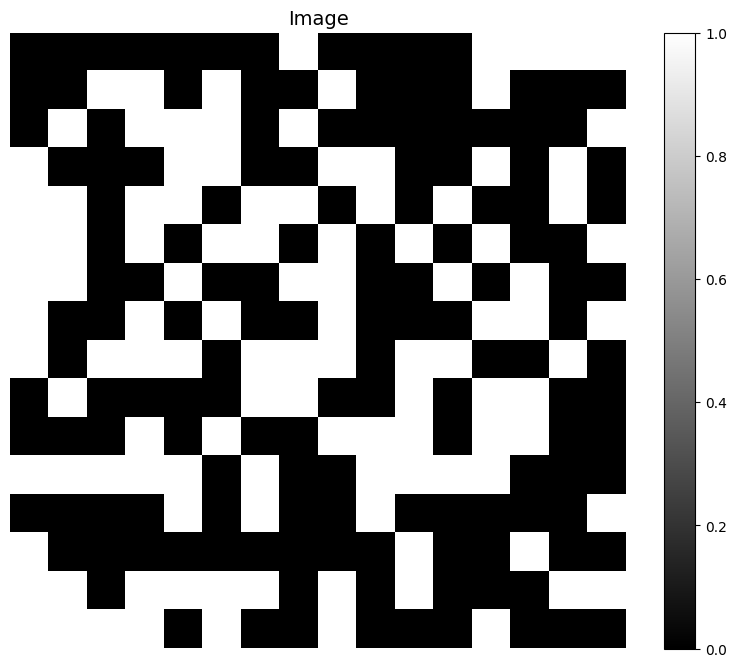

In [2]:
from qiskit_aer import AerSimulator
import os
import sys

base = os.path.dirname(os.getcwd())
grandparent = os.path.dirname(base)

notebook_dir = os.path.join(grandparent,"side_quests" ,"challenge_01_quantum_vision_fundamentals")
notebook_name = "frqi_challenge_fr"   # without .ipynb

# Add the folder to sys.path
sys.path.append(notebook_dir)

def random_patern(L1, L2) -> tuple[QuantumCircuit, int]:
    """
    Pedagogical FRQI encoder for a binary (black/white) image.

    Convention used here:
    - Pixel index i is converted to a "natural" bitstring (MSB on the left) with format(...).
    - position qubits are q0..q(k-1), where q0 is the LSB.
    - The helper _apply_x_mask(...) reverses the bitstring to align bits with q0..

    Steps:
    1) Put all positions in superposition (H on all position qubits).
    2) For each black pixel address, apply an X-mask + MCX + undo the mask.
    """
    n_pixels = L1*L2
    if n_pixels == 0:
        raise ValueError("Empty image.")

    n_pos = math.ceil(math.log2(n_pixels))  # number of position qubits
    n_total = n_pos + 1  # +1 color qubit
    pos_qubits = list(range(n_pos))  # q0..q(k-1)
    color_qubit = n_pos  # qk

    # Warn if there are more addresses than pixels
    if 2**n_pos > n_pixels:
        print(f"Note: 2^k = {2**n_pos} > N = {n_pixels} (extra addresses stay white)")

    # Create circuit
    qc = QuantumCircuit(n_total)

    # Step 1) Superposition over addresses
    for q in pos_qubits:
        qc.h(q)

    # Step 2) Encode black pixels with MC
    qc.h(color_qubit)

    print(f" FRQI circuit created!")
    print(f"   Depth: {qc.depth()}, Size: {qc.size()} gates")

    return qc, n_pos  # return circuit and number of position qubits


L1 = 16
L2 = 16
bits = []
for _ in range(L1*L2):
    qc  = QuantumCircuit(1)
    qc.h(0)
    qc.measure_all()

    
    sampler = AerSimulator(method="statevector")
    outcome_hex = list(
        sampler.run([qc.decompose(reps=1)], shots=1)
        .result()
        .data(0)["counts"]
        .keys()
    )[0]
    outcome_binary = format(int(outcome_hex, 16), f"0{1}b")
    bits.append(outcome_binary)

bm = np.array(bits).reshape(L1,L2).astype(float)
print(bm)
display_image(bm)

## Pattern 2 - Quantum Checkerboard

Create a classic checkerboard pattern, that is, alternating black and white pixels. The circuit is **deterministic**: it always produces the same checkerboard.

Can you also figure out how to obtain the negative from this first circuit?

![chess](images/chess.png)

Note: the checkerboard and its negative are reconstructed separately, using distinct circuits.

 FRQI circuit created!
   Depth: 3, Size: 8 gates
Reconstructing image from measurements...


Reconstructed image:
[[0 1 0 1 0 1 0 1]
 [1 0 1 0 1 0 1 0]
 [0 1 0 1 0 1 0 1]
 [1 0 1 0 1 0 1 0]
 [0 1 0 1 0 1 0 1]
 [1 0 1 0 1 0 1 0]
 [0 1 0 1 0 1 0 1]
 [1 0 1 0 1 0 1 0]]


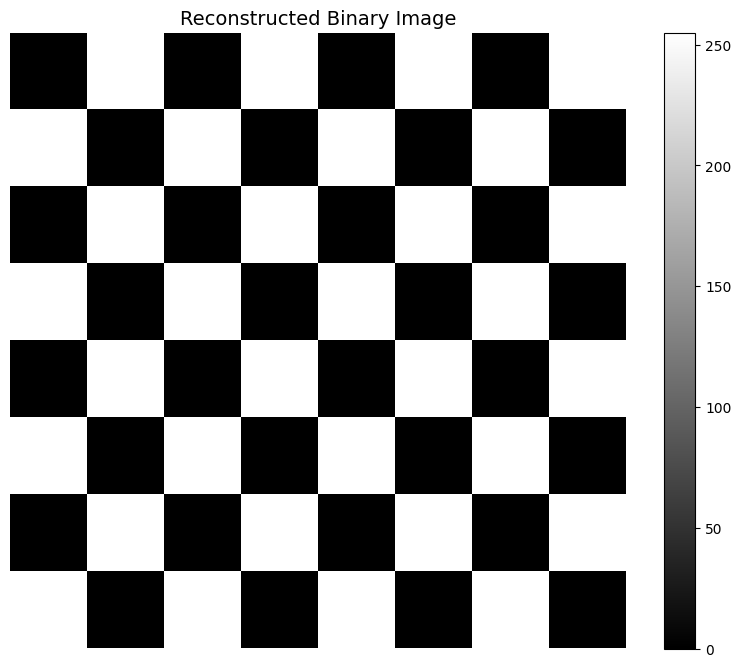

In [3]:
import utils_images

from grayscale import encode_frqi_grayscale, reconstruct_grayscale_from_frqi, reconstruct_from_frqi, encode_frqi_simple

def checker_patern(L1,L2,negative) -> tuple[QuantumCircuit, int]:
    """
    Pedagogical FRQI encoder for a binary (black/white) image.

    Convention used here:
    - Pixel index i is converted to a "natural" bitstring (MSB on the left) with format(...).
    - position qubits are q0..q(k-1), where q0 is the LSB.
    - The helper _apply_x_mask(...) reverses the bitstring to align bits with q0..

    Steps:
    1) Put all positions in superposition (H on all position qubits).
    2) For each black pixel address, apply an X-mask + MCX + undo the mask.
    """
    n_pixels = L1*L2
    if n_pixels == 0:
        raise ValueError("Empty image.")

    n_pos = math.ceil(math.log2(n_pixels))  # number of position qubits
    n_total = n_pos + 1  # +1 color qubit
    pos_qubits = list(range(n_pos))  # q0..q(k-1)
    color_qubit = n_pos  # qk

    # Warn if there are more addresses than pixels
    if 2**n_pos > n_pixels:
        print(f"Note: 2^k = {2**n_pos} > N = {n_pixels} (extra addresses stay white)")

    # Create circuit
    qc = QuantumCircuit(n_total)

    # Step 1) Superposition over addresses
    for q in pos_qubits:
        qc.h(q)

    # Step 2) Encode black pixels with MC
    qc.cx(0, color_qubit)
    qc.cx(n_pos//2, color_qubit)

    if negative:
        qc.x(color_qubit)

    print(f" FRQI circuit created!")
    print(f"   Depth: {qc.depth()}, Size: {qc.size()} gates")

    return qc, n_pos  # return circuit and number of position qubits

L1 = 8
L2 = 8
pixel_grid = []

checker_circ, n_pos = checker_patern(L1,L2,False)
checker_circ.measure_all()
num_shots = (2**n_pos) * 50
counts = utils_quantum.run_simulation(checker_circ, shots=num_shots)

# Reconstruct
frqi_reconstructed = reconstruct_from_frqi(counts, n_pos, (L1,L2))

print(f"\n{'='*60}")
print("Reconstructed image:")
print(frqi_reconstructed)

display_image(frqi_reconstructed * 255, "Reconstructed Binary Image")

## Pattern 3 - Horizontal Lines
You must generate alternating black and white horizontal lines that remain the same between each run.

![Horizontal lines](images/frqi_bar_horiz.png)

 FRQI circuit created!
   Depth: 2, Size: 7 gates
Reconstructing image from measurements...


Reconstructed image:
[[0 0 0 0 0 0 0 0]
 [1 1 1 1 1 1 1 1]
 [0 0 0 0 0 0 0 0]
 [1 1 1 1 1 1 1 1]
 [0 0 0 0 0 0 0 0]
 [1 1 1 1 1 1 1 1]
 [0 0 0 0 0 0 0 0]
 [1 1 1 1 1 1 1 1]]


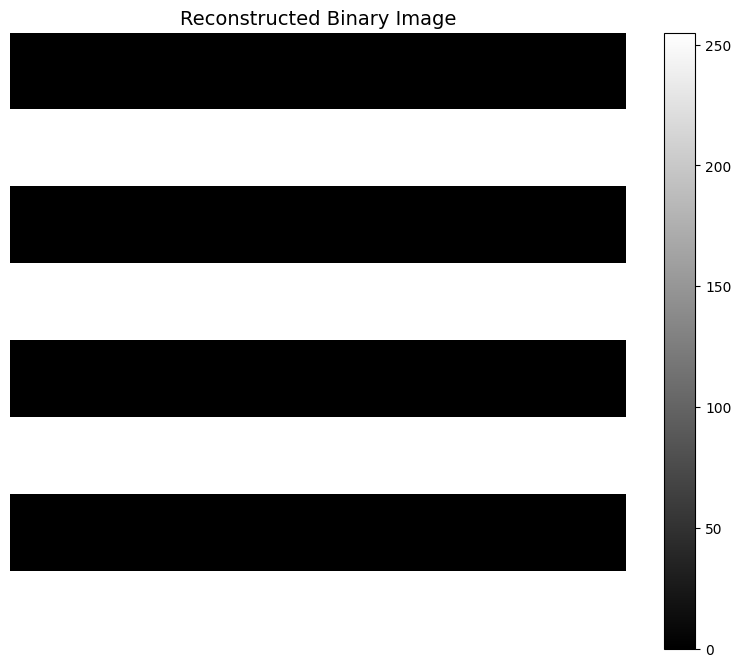

In [4]:
import utils_images

from grayscale import encode_frqi_grayscale, reconstruct_grayscale_from_frqi, reconstruct_from_frqi

def checker_patern(L1,L2,negative) -> tuple[QuantumCircuit, int]:
    """
    Pedagogical FRQI encoder for a binary (black/white) image.

    Convention used here:
    - Pixel index i is converted to a "natural" bitstring (MSB on the left) with format(...).
    - position qubits are q0..q(k-1), where q0 is the LSB.
    - The helper _apply_x_mask(...) reverses the bitstring to align bits with q0..

    Steps:
    1) Put all positions in superposition (H on all position qubits).
    2) For each black pixel address, apply an X-mask + MCX + undo the mask.
    """
    n_pixels = L1*L2
    if n_pixels == 0:
        raise ValueError("Empty image.")

    n_pos = math.ceil(math.log2(n_pixels))  # number of position qubits
    n_total = n_pos + 1  # +1 color qubit
    pos_qubits = list(range(n_pos))  # q0..q(k-1)
    color_qubit = n_pos  # qk

    # Warn if there are more addresses than pixels
    if 2**n_pos > n_pixels:
        print(f"Note: 2^k = {2**n_pos} > N = {n_pixels} (extra addresses stay white)")

    # Create circuit
    qc = QuantumCircuit(n_total)

    # Step 1) Superposition over addresses
    for q in pos_qubits:
        qc.h(q)

    # Step 2) Encode black pixels with MC
    qc.cx(n_pos//2, color_qubit)

    if negative:
        qc.x(color_qubit)

    print(f" FRQI circuit created!")
    print(f"   Depth: {qc.depth()}, Size: {qc.size()} gates")

    return qc, n_pos  # return circuit and number of position qubits

L1 = 8
L2 = 8
pixel_grid = []

checker_circ, n_pos = checker_patern(L1,L2,False)
checker_circ.measure_all()
num_shots = (2**n_pos) * 50
counts = utils_quantum.run_simulation(checker_circ, shots=num_shots)

# Reconstruct
frqi_reconstructed = reconstruct_from_frqi(counts, n_pos, (L1,L2))

print(f"\n{'='*60}")
print("Reconstructed image:")
print(frqi_reconstructed)

display_image(frqi_reconstructed * 255, "Reconstructed Binary Image")

## Pattern 4 - Vertical Lines
Same idea as pattern 3, but the lines must be vertical just like in the picture below.

![Vertical lines](images/frqi_bar_ver.png)

 FRQI circuit created!
   Depth: 2, Size: 7 gates
Reconstructing image from measurements...


Reconstructed image:
[[0 1 0 1 0 1 0 1]
 [0 1 0 1 0 1 0 1]
 [0 1 0 1 0 1 0 1]
 [0 1 0 1 0 1 0 1]
 [0 1 0 1 0 1 0 1]
 [0 1 0 1 0 1 0 1]
 [0 1 0 1 0 1 0 1]
 [0 1 0 1 0 1 0 1]]


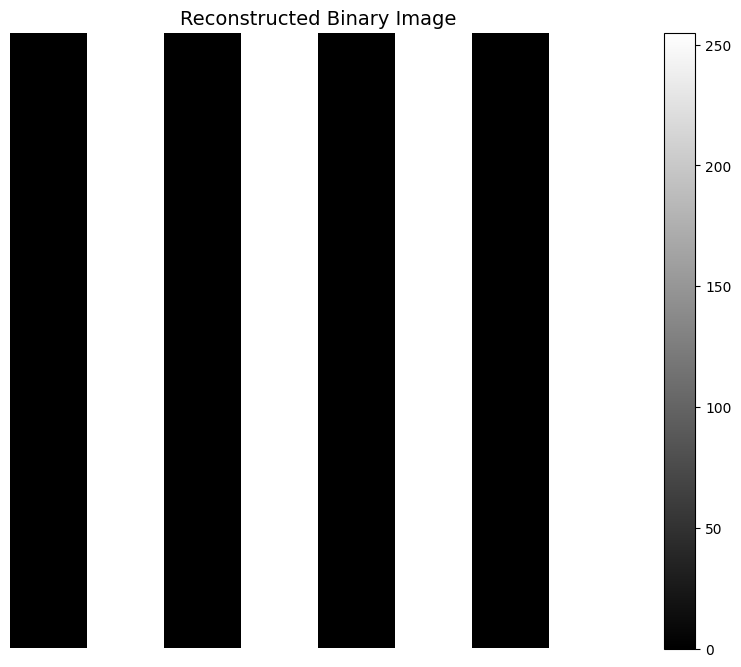

In [5]:
import utils_images

from grayscale import encode_frqi_grayscale, reconstruct_grayscale_from_frqi, reconstruct_from_frqi

def checker_patern(L1,L2,negative) -> tuple[QuantumCircuit, int]:
    """
    Pedagogical FRQI encoder for a binary (black/white) image.

    Convention used here:
    - Pixel index i is converted to a "natural" bitstring (MSB on the left) with format(...).
    - position qubits are q0..q(k-1), where q0 is the LSB.
    - The helper _apply_x_mask(...) reverses the bitstring to align bits with q0..

    Steps:
    1) Put all positions in superposition (H on all position qubits).
    2) For each black pixel address, apply an X-mask + MCX + undo the mask.
    """
    n_pixels = L1*L2
    if n_pixels == 0:
        raise ValueError("Empty image.")

    n_pos = math.ceil(math.log2(n_pixels))  # number of position qubits
    n_total = n_pos + 1  # +1 color qubit
    pos_qubits = list(range(n_pos))  # q0..q(k-1)
    color_qubit = n_pos  # qk

    # Warn if there are more addresses than pixels
    if 2**n_pos > n_pixels:
        print(f"Note: 2^k = {2**n_pos} > N = {n_pixels} (extra addresses stay white)")

    # Create circuit
    qc = QuantumCircuit(n_total)

    # Step 1) Superposition over addresses
    for q in pos_qubits:
        qc.h(q)

    # Step 2) Encode black pixels with MC
    qc.cx(0, color_qubit)

    if negative:
        qc.x(color_qubit)

    print(f" FRQI circuit created!")
    print(f"   Depth: {qc.depth()}, Size: {qc.size()} gates")

    return qc, n_pos  # return circuit and number of position qubits

L1 = 8
L2 = 8
pixel_grid = []

checker_circ, n_pos = checker_patern(L1,L2,False)
checker_circ.measure_all()
num_shots = (2**n_pos) * 50
counts = utils_quantum.run_simulation(checker_circ, shots=num_shots)

# Reconstruct
frqi_reconstructed = reconstruct_from_frqi(counts, n_pos, (L1,L2))

print(f"\n{'='*60}")
print("Reconstructed image:")
print(frqi_reconstructed)

display_image(frqi_reconstructed * 255, "Reconstructed Binary Image")

## Pattern 5 - Nested Squares

Here, we want to build concentric rectangles, that is, nested squares that alternate black and white from the outside toward the center. In contrast to the checkerboard and the stripes patterns, each pixel must be handled individually.

To describe this pattern, we consider an image of size $R \times C$:
- $R$ = number of rows
- $C$ = number of columns

For a pixel located at row $r$ and column $c$, we define its **layer** $L(r,c)$ as its distance to the nearest border:

$$
L(r,c) = \min(r, c, R-1-r, C-1-c)
$$

Thus:
- layer $0$ corresponds to the outer border,
- layer $1$ to the first inner rectangle,
- layer $2$ to the next one,
- and so on until the center.

**Your goal:** find an FRQI circuit that reproduces this pattern while respecting the black/white alternation.

![Concentric rectangles](images/frqi_carre.png)

 FRQI circuit created!
   Depth: 431, Size: 1304 gates
Reconstructing image from measurements...



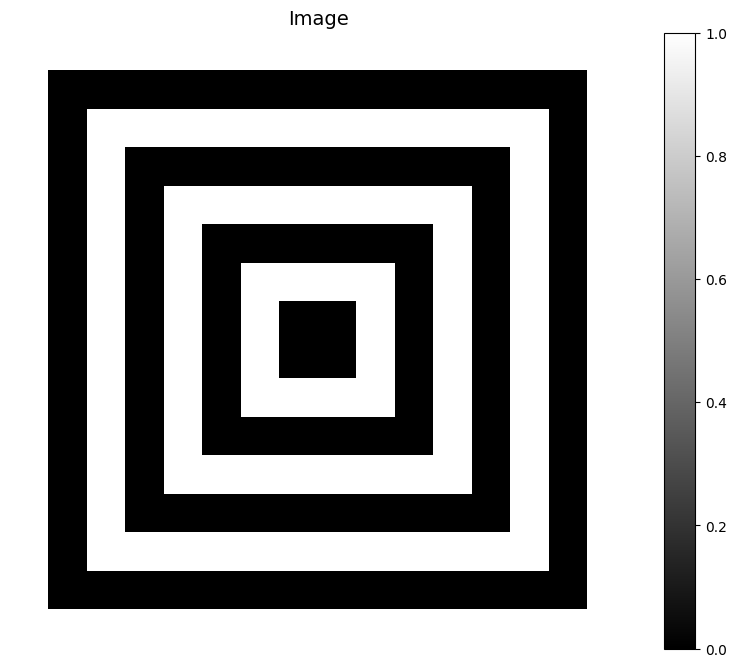

In [6]:


L1 = 16
L2 = 16
def layer(r,c,R,C):
    return min(r,c,R-1-r,C-1-c)

bits = np.zeros(L1*L2)
for q in range(L1*L2):
    if layer(q//L1, q%L2, L1,L2)%2==0:
        bits[q] = 1

bm = np.array(bits).reshape(L1,L2).astype(float)

square_circ, n_pos = encode_frqi_simple(bm)

square_circ.measure_all()
num_shots = (2**n_pos) * 50
counts = utils_quantum.run_simulation(square_circ, shots=num_shots)

# Reconstruct
frqi_reconstructed = reconstruct_from_frqi(counts, n_pos, (L1,L2))

display_image(frqi_reconstructed)


## Pattern 6 - Grayscale Nested Squares

Same idea as the Nested Squares in pattern 5, but **each layer has a different intensity**.
You can find how to handle grayscale images using FRQI encoding in challenge 1 Image Lab.

![Grayscale rectangles](images/frqi_carre_gris.png)

/Users/ludovic/Library/CloudStorage/OneDrive-NordQuantique(Acet)/Documents/hackaton/compile-moi-si-tu-peux/iqucodefest-2026-docs/side_quests/challenge_01_quantum_vision_fundamentals
['grayscale.py', 'frqi_challenge_fr.ipynb', 'utils_quantum.py', 'utils_images.py', '__pycache__', 'frqi_challenge_en.ipynb']
[[255.    255.    255.    255.    255.    255.    255.    255.    255.
  255.    255.    255.    255.    255.    255.    255.   ]
 [255.    223.125 223.125 223.125 223.125 223.125 223.125 223.125 223.125
  223.125 223.125 223.125 223.125 223.125 223.125 255.   ]
 [255.    223.125 191.25  191.25  191.25  191.25  191.25  191.25  191.25
  191.25  191.25  191.25  191.25  191.25  223.125 255.   ]
 [255.    223.125 191.25  159.375 159.375 159.375 159.375 159.375 159.375
  159.375 159.375 159.375 159.375 191.25  223.125 255.   ]
 [255.    223.125 191.25  159.375 127.5   127.5   127.5   127.5   127.5
  127.5   127.5   127.5   159.375 191.25  223.125 255.   ]
 [255.    223.125 191.25  159.375 

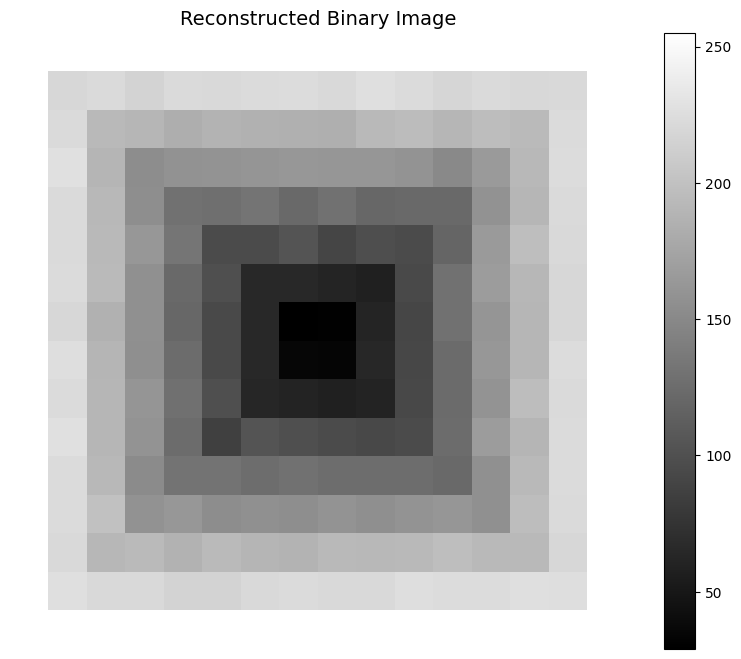

In [7]:
import os
import sys

base = os.path.dirname(os.getcwd())
grandparent = os.path.dirname(base)

notebook_dir = os.path.join(grandparent,"side_quests" ,"challenge_01_quantum_vision_fundamentals")
notebook_name = "frqi_challenge_fr"   # without .ipynb

# Add the folder to sys.path
sys.path.append(notebook_dir)
print(notebook_dir)
print(os.listdir(notebook_dir))

from grayscale import encode_frqi_grayscale, reconstruct_grayscale_from_frqi

L1 = 16
L2 = 16
def layer(r,c,R,C):
    return min(r,c,R-1-r,C-1-c)

n_layers = L1//2

grayscale = np.zeros((L1,L2))
for q in range(L1*L2):
    l = layer(q//L1, q%L2, L1,L2)
    grayscale[q//L1, q%L2] = 255 - l/n_layers*255
print(grayscale)

# Build FRQI circuit
frqi_circuit, n_pos = encode_frqi_grayscale(grayscale)

# very important: add measurement to the circuit
frqi_circuit.measure_all()

num_shots = 1000 * (2**n_pos) # 200 shots per pixel address
counts = utils_quantum.run_simulation(frqi_circuit, shots=num_shots)

# Reconstruct
frqi_reconstructed = reconstruct_grayscale_from_frqi(counts, n_pos, grayscale.shape)

print(f"\n{'='*60}")
print("Reconstructed image:")
print(frqi_reconstructed)

display_image(frqi_reconstructed, "Reconstructed Binary Image")

## Pattern 7 - Quantum Sierpiński Triangle (Bonus)
This challenge consists of building **a single FRQI circuit** that allows you to reconstruct:
- the **normal** image;
- the **inverted** image.

![Sierpiński triangle](images/fractal.png)

The idea is that after taking **many measurements**, you obtain **two groups of results** depending on the value of a **selection qubit**, and then you reconstruct one image per group.

The **classical mask** necessary to build the fractal is given below.

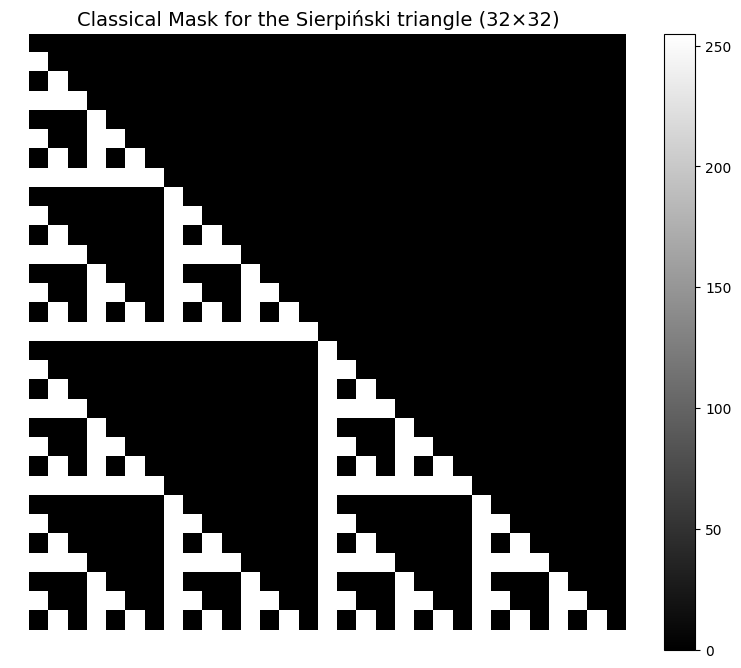

[[1 0 0 ... 0 0 0]
 [1 1 0 ... 0 0 0]
 [1 0 1 ... 0 0 0]
 ...
 [1 1 0 ... 1 0 0]
 [1 0 1 ... 0 1 0]
 [1 1 1 ... 1 1 1]]


In [8]:
def sierpinski_triangle_mask(size=32):
    """Return a binary mask (size x size) for the Sierpiński triangle."""
    mask = np.zeros((size, size), dtype=int)
    for row in range(size):
        for col in range(size):
            if col <= row and (row & col) == col:
                mask[row, col] = 1
    return mask


size = 32
mask = sierpinski_triangle_mask(size)
display_image(mask * 255, f"Classical Mask for the Sierpiński triangle ({size}×{size})", cmap='gray')

print(mask)

 FRQI circuit created!
   Depth: 729, Size: 2685 gates
Reconstructing image from measurements...



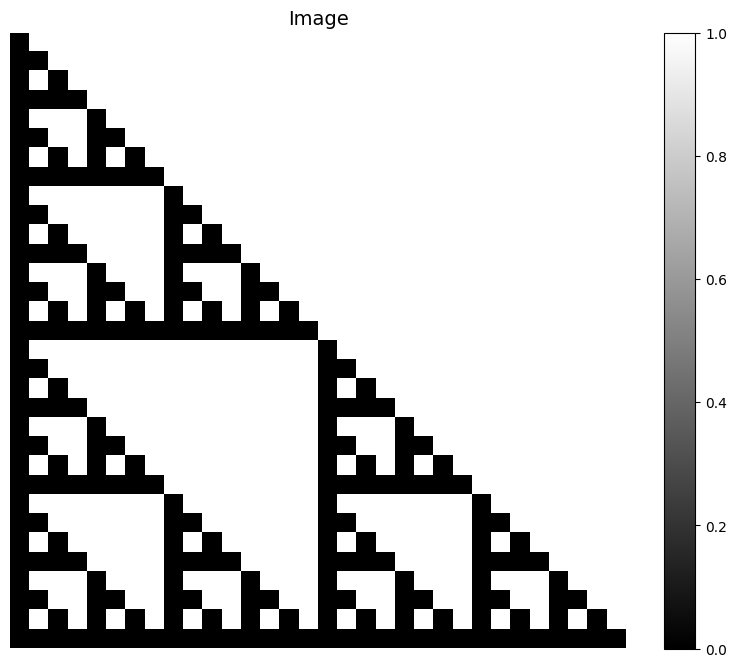

Reconstructing image from measurements...



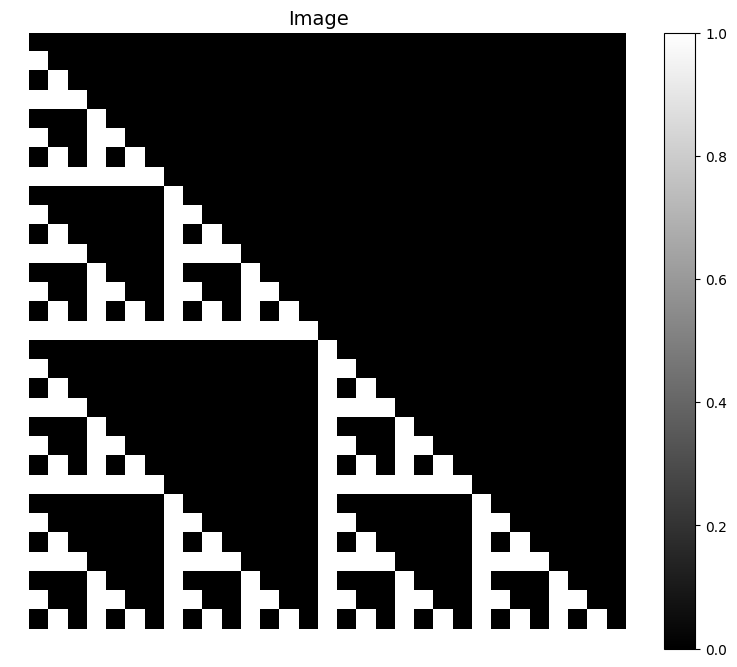

In [9]:
def _apply_x_mask(qc: QuantumCircuit, address_bitstring: str, position_qubits: list[int]):
    """
    Apply an X-mask to emulate controls-on-0 for an address.

    Why:
    - A standard MCX triggers only when all control qubits are |1>.
    - If an address bit is 0, we temporarily flip the corresponding qubit with X
      so that MCX can trigger, then we undo the mask later.

    Args:
    - qc: QuantumCircuit to modify.
    - address_bitstring: "natural" binary string (MSB on the left), e.g. "0101".
    - position_qubits: ordered list of position-qubit indices (q0 = LSB).
      Note: if position_qubits == [0, 1, 2, ...], then position_qubits[i] == i.
    """
    # Reverse so index 0 aligns with q0 (LSB)
    for bit_idx, bit in enumerate(reversed(address_bitstring)):
        if bit == "0":
            qc.x(position_qubits[bit_idx])

def encode_frqi_test(binary_image: np.ndarray) -> tuple[QuantumCircuit, int]:
    """
    Pedagogical FRQI encoder for a binary (black/white) image.

    Convention used here:
    - Pixel index i is converted to a "natural" bitstring (MSB on the left) with format(...).
    - position qubits are q0..q(k-1), where q0 is the LSB.
    - The helper _apply_x_mask(...) reverses the bitstring to align bits with q0..

    Steps:
    1) Put all positions in superposition (H on all position qubits).
    2) For each black pixel address, apply an X-mask + MCX + undo the mask.
    """
    flat = np.array(binary_image).astype(int).flatten() # flatten to 1D array row-major order: row0, row1, ...
    n_pixels = len(flat)
    if n_pixels == 0:
        raise ValueError("Empty image.")

    n_pos = math.ceil(math.log2(n_pixels)) # number of position qubits
    n_total = n_pos + 2                  # +1 color qubit + 1 selection qubit
    pos_qubits = list(range(n_pos))       # q0..q(k-1)
    color_qubit = n_pos                   # qk         
    selection_qubit = n_pos + 1                 # q(k+1)     

    # Warn if there are more addresses than pixels
    if 2**n_pos > n_pixels:
        print(f"Note: 2^k = {2**n_pos} > N = {n_pixels} (extra addresses stay white)")
    
    # Create circuit
    qc = QuantumCircuit(n_total)
    
    # Step 1) Superposition over addresses
    for q in pos_qubits:
        qc.h(q)

    qc.h(selection_qubit)

    # Step 2) Encode black pixels with MCX

    for i, pixel_val in enumerate(flat):
        if int(pixel_val) != 1:         # only encode black pixels (value 1)
            continue

        address_bitstring = format(i, f"0{n_pos}b")  # MSB..LSB (natural)

        _apply_x_mask(qc, address_bitstring, pos_qubits) # apply X-mask for controls-on-0
        qc.mcx(pos_qubits, color_qubit)                  # Multi-controlled X: flip color qubit when ALL position qubits are |1⟩
        _apply_x_mask(qc, address_bitstring, pos_qubits)  # undo (X is its own inverse)

        qc.barrier() # barrier for visual clarity

    qc.cx(selection_qubit, color_qubit)
     # Note: MCX can apply the sandwiching X gates automatically with the ctrl_state option,

    
    print(f" FRQI circuit created!")
    print(f"   Depth: {qc.depth()}, Size: {qc.size()} gates")
    
    return qc, n_pos # return circuit and number of position qubits


def reconstruct_from_frqi_2(counts, n_position_qubits, image_shape):
    """
    Reconstruct image from FRQI measurement counts using the 'Ratio' method.
    Args:
    - counts: dict from measurement outcomes to counts.
    - n_position_qubits: number of position qubits used in FRQI.
    - image_shape: tuple (height, width) of the original image.
    
    Returns:
    - reconstructed_image: 2D numpy array of the reconstructed image.
    """
    
    n_pixels = image_shape[0] * image_shape[1] # Total number of pixels
    
    # 1. Accumulate statistics per pixel (Address)
    total_counts = np.zeros(n_pixels, dtype=int)
    ones_counts = np.zeros(n_pixels, dtype=int)
    
    print("Reconstructing image from measurements...\n")
    
    # For each measurement outcome (e.g., '10101')
    for outcome, count in counts.items():
        # Remove spaces if any
        outcome = outcome.replace(" ", "")
        
        # --- VISUAL MAPPING (Left -> High Index) ---
        # The string typically looks like: "C P3 P2 P1 P0"
        # Leftmost character is the Color Qubit
        color_char = outcome[1] 
        
        # The rest is the Position (binary string)
        position_string = outcome[2:]
        
        # Convert "1101" -> 13 (Standard binary: Left is MSB)
        position_idx = int(position_string, 2)

        
        # Only process valid pixel positions
        if position_idx < n_pixels:
            # Accumulate counts for this address
            total_counts[position_idx] += count
            
            # If color bit is 1, count it as a "black" measurement
            if int(color_char) == 1:
                ones_counts[position_idx] += count
    
    # 2. Compute Pixel Values based on Ratio
    reconstructed = np.zeros(n_pixels, dtype=int)
    
    for i in range(n_pixels):
        if total_counts[i] > 0:
            # Calculate proportion of 1s (Intensity)
            ratio = ones_counts[i] / total_counts[i]
            
            # For Binary: Threshold at 50%
            if ratio > 0.5:
                reconstructed[i] = 1
    
    # Reshape to original image dimensions
    reconstructed_image = reconstructed.reshape(image_shape) # from 1D to 2D, row-major order
    
    return reconstructed_image




L1 = 32
L2 = 32


circ, n_pos = encode_frqi_test(mask)
circ.measure_all()
num_shots = (2**n_pos) * 1000
counts = utils_quantum.run_simulation(circ, shots=num_shots)

counts_1 = {key: value for key, value in counts.items() if key[0] == '1'}  # Only keep outcomes where color qubit is 1

counts_2 = {key: value for key, value in counts.items() if key[0] == '0'}  # Only keep outcomes where color qubit is 0

# Reconstruct
frqi_reconstructed = reconstruct_from_frqi_2(counts_1, n_pos, (L1,L2))

display_image(frqi_reconstructed)

frqi_reconstructed = reconstruct_from_frqi_2(counts_2, n_pos, (L1,L2))

display_image(frqi_reconstructed)


